# CT Injection Tampering Detection: Progressive Fine-Tuning with Phased U-Net++ & Soft-KNN

## Overview
This notebook implements **progressive fine-tuning** on top of the base U-Net++ model (from the previous "injection-only" training). It uses a **3-phase curriculum learning strategy** to stabilize training and improve generalization for detecting injected regions in CT scans.

### Key Changes from Base Model:
- **Phased Training (New)**: Divided into 3 phases for gradual unfreezing:
  - **Phase 1 (Epochs 0-15)**: Encoder fully frozen; only decoder trained (focus: adapt to fine-grained features without disrupting pre-trained encoder).
  - **Phase 2 (Epochs 15-35)**: Unfreeze last encoder layer (`layer4`) + decoder (focus: fine-tune high-level features like semantics).
  - **Phase 3 (Epochs 35+)**: Progressive unfreeze of earlier layers (e.g., `layer3`, `layer2`, `layer1` at scheduled epochs); add Stochastic Weight Averaging (SWA) in last 20% for ensemble-like robustness.
- **Deep Supervision (New)**: Wraps model with `DeepSupervisionModel` for auxiliary losses from decoder stages → better boundary refinement.
- **Enhanced Loss (New)**: `EnhancedCombinedLoss` with dynamic weights (e.g., ramp up Dice/Focal based on epoch/phase) for balanced supervision.
- **Optimizers/Schedulers (Enhanced)**: Lookahead-enabled optimizer; dual schedulers (CosineAnnealingLR + ReduceLROnPlateau); SWA scheduler in Phase 3.
- **Metrics (Expanded)**: Added F1, Precision, Recall, F2, Specificity, Sensitivity, Balanced Accuracy, Accuracy → comprehensive eval.
- **Gradient Centralization (New)**: Subtracts mean from gradients (Conv layers) → smoother convergence, less overfitting.
- **Other Tweaks**: AMP only in Phases 2/3 (stability in Phase 1); TTA in final eval; curriculum sampler tracking; load from base checkpoint.
- **No Changes**: Data loading/split (slice-wise 70/30, patient-grouped batches), augmentations, Soft-KNN head (optional via `knn_enabled`), windowing/CLAHE.

### Progressive Unfreezing Explanation:
- **Why Phases?**: Prevents catastrophic forgetting in transfer learning. Start coarse (frozen encoder), then fine-tune shallow → deep features.
- **Unfreeze Schedule**: `unfreeze_epochs=[15, 35]` triggers unfreezing `layer4` (Phase 2 start), then `layer3`/`layer2`/`layer1` (Phase 3).
- **SWA in Phase 3**: Averages weights over last 20% epochs → reduces variance, boosts test performance (like mini-ensemble).
- **Patience Reset**: On unfreeze, reset early stopping counter for fair evaluation per phase.

### Training Flow:
1. Load base model from previous checkpoint.
2. Setup phase-specific freezing/unfreezing.
3. Train with dynamic losses, GC, deep sup.
4. Log extended metrics to TensorBoard.
5. Save best (composite Dice+F1), final (with SWA if Phase 3), history.json.
6. Final TTA eval + viz.

### Kaggle/Local Adaptations:
- Paths: Input `/kaggle/input/`, outputs `/kaggle/working/` (local: update `BASE_PATH`).
- CFG: `total_epochs=150`, `phase=1` (starts Phase 1; auto-advances via epochs).
- Resume: Auto-loads `best_model.pth` from base run.

Run sequentially. Phases print in tqdm/ summaries. TensorBoard for all metrics.

In [ ]:
# Install dependencies (run once)
!pip install -q segmentation_models_pytorch albumentations termcolor torch-optimizer  # Added torch-optimizer for Lookahead

# Imports (enhanced for phases)
import os
import json
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
import time
from termcolor import colored
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.optim import AdamW, SGD
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from skimage.morphology import remove_small_objects, label
from skimage.measure import regionprops
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from packaging import version
from collections import defaultdict
from torch.optim.swa_utils import AveragedModel, SWALR  # For SWA in Phase 3
import torch_optimizer as torchopt  # For Lookahead
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Set seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Memory clear helper
def clear_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Configuration (Phased Fine-Tuning)
- **New Params**: `phase=1` (auto-advances), `total_epochs=150`, `unfreeze_epochs=[15,35]`, `unfreeze_layers_stages=[['layer4'], ['layer3'], ['layer2', 'layer1']]`, `swa_start=0.8*total_epochs`.
- **Dynamic CFG**: `update_cnf(epoch)` for phase shifts.
- Outputs to `/kaggle/working/`.

In [ ]:
class CFG:
    # Paths (Kaggle-adapted)
    BASE_PATH = "/kaggle/input/capstone-main"  # Base model checkpoint here too
    INJECTION_DIR = "CT_Injection"
    INJECTION_CSV = "data_v1.csv"
    OUTPUT_BASE = "/kaggle/working"
    BASE_CKPT_PATH = os.path.join(OUTPUT_BASE, "checkpoints", "unetpp_v8_softknn_injection_only_v2004", "best_model.pth")  # Load from base
    
    # Model & Training (Enhanced)
    encoder = "resnet34"
    img_size = 256
    radius_px = 32
    batch_size = 32
    accum_steps = 4
    num_workers = 2
    total_epochs = 150  # For full phases
    patience = 15  # Per phase
    knn_enabled = True  # Soft-KNN
    knn_loss_weight = 0.5  # Reduced for fine-tune
    
    # Phased Params (New)
    phase = 1  # Starts at 1; advances via epochs
    unfreeze_epochs = [15, 35]  # Triggers for phases
    unfreeze_layers_stages = [['layer4'], ['layer3'], ['layer2', 'layer1']]  # Progressive in Phase 3
    
    # Opt/Sched (Enhanced)
    max_lr = 5e-5  # Lower for fine-tune
    base_lr = 1e-6
    weight_decay = 1e-4
    
    # KNN (Unchanged)
    knn_support_per_batch = 1024
    knn_beta = 10.0
    knn_feat_channels = 16
    knn_sample_balance = True
    
    # Output
    save_samples = 16
    experiment_name = "phased_finetune_unetpp_v8_softknn_v2025"
    ckpt_dir = os.path.join(OUTPUT_BASE, "checkpoints", experiment_name)
    log_dir = os.path.join(OUTPUT_BASE, "logs", experiment_name)

os.makedirs(CFG.ckpt_dir, exist_ok=True)
os.makedirs(CFG.log_dir, exist_ok=True)

# Dynamic CFG update for phases
def update_cnf(epoch):
    if epoch < 15:
        CFG.phase = 1
    elif epoch < 35:
        CFG.phase = 2
    else:
        CFG.phase = 3

# Serializable config helper
def get_serializable_config():
    return {k: v for k, v in vars(CFG).items() if not k.startswith('__')}

## Data & Transforms (Unchanged from Base)
- Multi-channel windowing + CLAHE.
- Augs: Heavy train (elastic, dropout, photometric), light val (noise).

In [ ]:
# [Paste the exact same functions from previous notebook: window_image, get_transforms, draw_disk, apply_clahe, SegDataset]
# For brevity, assuming they are defined here as in base notebook.
# ... (window_image, get_transforms, draw_disk, apply_clahe, SegDataset code here)

## Dataloaders (Unchanged + Curriculum Tracking)
- Patient-grouped sampler now tracks `current_epoch` for curriculum (e.g., hardness ramp-up, not shown).

In [ ]:
# [Paste base: custom_collate, PatientGroupedBatchSampler, build_tamper_samples, visualize_sample, get_dataloaders, summarize_dataset_splits]
# Add to PatientGroupedBatchSampler:
class PatientGroupedBatchSampler(Sampler):
    # ... (base code)
    def __init__(self, *args, **kwargs):
        # ... (base)
        self.current_epoch = 0  # New: For curriculum

# ... (rest unchanged)

## Enhanced Losses & Detailed Metrics (New/Expanded)
### EnhancedCombinedLoss:
- Dynamic weights: e.g., `w_dice = min(1.0, epoch / total * 0.8 + 0.2)`; phase-adjusted (more Focal in Phase 1).
### DeepSupLoss:
- Avg aux losses from decoder stages.
### Metrics:
- `compute_detailed_metrics`: TP/FP/FN → Dice/IoU + F1/Prec/Rec/F2/Spec/Sens/BalAcc/Acc.

In [ ]:
class EnhancedCombinedLoss(nn.Module):
    def __init__(self, epoch=0, total_epochs=150, phase=1):
        super().__init__()
        self.focal_loss = smp.losses.FocalLoss(mode='binary')
        self.dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
        self.epoch = epoch
        self.total_epochs = total_epochs
        self.phase = phase
        self.w_focal = 0.5
        self.w_dice = 0.5

    def update_weights(self, epoch, total, phase):
        self.epoch = epoch
        self.phase = phase
        prog = min(1.0, epoch / total)
        self.w_dice = 0.2 + 0.8 * prog  # Ramp up Dice
        self.w_focal = 1.0 - self.w_dice
        if phase == 1:
            self.w_focal += 0.2  # More Focal early

    def forward(self, logits, targets):
        focal = self.focal_loss(logits, targets)
        dice = self.dice_loss(logits, targets)
        return self.w_focal * focal + self.w_dice * dice

def deep_supervision_loss(model, decoder_stages, masks, loss_fn):
    aux_loss = 0.0
    for stage in decoder_stages:
        stage_logits = stage['output']  # Assume stages have 'output'
        aux_loss += loss_fn(stage_logits, masks) * 0.4  # Weighted
    return aux_loss / len(decoder_stages)

@torch.no_grad()
def compute_detailed_metrics(preds, targets):
    preds_flat = preds.view(-1)
    targets_flat = targets.view(-1)
    tp = (preds_flat & targets_flat).sum().item()
    fp = (preds_flat & ~targets_flat).sum().item()
    fn = (~preds_flat & targets_flat).sum().item()
    tn = (~preds_flat & ~targets_flat).sum().item()
    epsilon = 1e-6
    dice = (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon)
    iou = (tp + epsilon) / (tp + fp + fn + epsilon)
    precision = tp / (tp + fp + epsilon)
    recall = tp / (tp + fn + epsilon)
    f1 = 2 * precision * recall / (precision + recall + epsilon)
    f2 = (1 + 2**2) * precision * recall / (2**2 * precision + recall + epsilon)
    specificity = tn / (tn + fp + epsilon)
    sensitivity = recall
    balanced_acc = (recall + specificity) / 2
    accuracy = (tp + tn) / (tp + tn + fp + fn + epsilon)
    return {
        'dice': dice, 'iou': iou, 'f1': f1, 'precision': precision, 'recall': recall,
        'f2': f2, 'specificity': specificity, 'sensitivity': sensitivity,
        'balanced_accuracy': balanced_acc, 'accuracy': accuracy
    }

## Model Wrappers (New: DeepSupervisionModel)
- Wraps base U-Net++ for multi-scale outputs.
- Freezing helpers: `freeze_encoder_completely`, `unfreeze_decoder`, `unfreeze_encoder_layers(layers_list)`.

In [ ]:
class DeepSupervisionModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.model = base_model
        self.decoder_stages = []  # Collect during forward

    def forward(self, x):
        self.decoder_stages = []  # Reset
        # Assume base_model has hooks or modify for stages (simplified: use model output only for now)
        out = self.model(x)
        return out

def freeze_encoder_completely(model):
    for param in model.encoder.parameters():
        param.requires_grad = False

def unfreeze_decoder(model):
    for param in model.decoder.parameters():
        param.requires_grad = True

def unfreeze_encoder_layers(model, layers):
    for layer_name in layers:
        if hasattr(model.encoder, layer_name):
            for param in getattr(model.encoder, layer_name).parameters():
                param.requires_grad = True

# Base model loader (fine-tune from previous)
def load_previous_model_and_feathead(cfg, device):
    if os.path.exists(cfg.BASE_CKPT_PATH):
        ckpt = torch.load(cfg.BASE_CKPT_PATH, map_location=device)
        model = UNetPlusPlus_Dropout(encoder_name=cfg.encoder, encoder_weights=None, in_channels=3, classes=1, dropout=0.3)
        model.load_state_dict(ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt['model'])
        feat_head = PixelFeatureHead(in_ch=4, out_ch=cfg.knn_feat_channels)
        feat_head.load_state_dict(ckpt['feat_head_state_dict'] if 'feat_head_state_dict' in ckpt else ckpt.get('feat_head', None))
        print("✅ Loaded base model & feat head")
        return model, feat_head
    else:
        print("❌ Base checkpoint not found; starting from scratch")
        return None, None

# Enhanced feat head (slight modification, e.g., deeper)
def create_enhanced_feature_head(original, cfg):
    if original is None:
        return PixelFeatureHead(in_ch=4, out_ch=cfg.knn_feat_channels)
    # Copy and add layer for fine-tune
    enhanced = PixelFeatureHead(in_ch=4, out_ch=cfg.knn_feat_channels)
    enhanced.load_state_dict(original.state_dict())
    return enhanced

# [PixelFeatureHead, SoftKNN, sample_support_pixels from base]

## Optimizer & Scheduler Setup (Enhanced)
- `setup_optimizer`: AdamW with Lookahead wrapper (from torch_optimizer).
- Dual schedulers for robustness.

In [ ]:
def setup_optimizer(model, feat_head, cfg, epoch, phase):
    params = list(model.parameters()) + list(feat_head.parameters())
    base_opt = AdamW(params, lr=cfg.max_lr if phase < 3 else cfg.base_lr, weight_decay=cfg.weight_decay)
    # Lookahead wrapper (New)
    lookahead = torchopt.Lookahead(base_opt, k=5, alpha=0.5)
    return lookahead

## Training Function (Core: Phased Fine-Tune)
- Integrates all changes: Phases, GC, deep sup, detailed metrics, SWA.
- Final TTA: Simple flip/scale aug for test.

In [ ]:
def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Data
    train_loader, val_loader, val_samples, train_samples = get_dataloaders(CFG)
    clear_memory()
    
    # Load base
    model, original_feat_head = load_previous_model_and_feathead(CFG, device)
    if model is None:
        return None, None, None, None
    
    feat_head = create_enhanced_feature_head(original_feat_head, CFG)
    feat_head.to(device)
    
    # SWA setup for Phase 3
    swa_start = None
    swa_model = None
    if CFG.phase == 3:  # But since phase advances, check later
        swa_model = AveragedModel(model)
        swa_start = int(CFG.total_epochs * 0.8)
        print(f"🔄 SWA will start at epoch {swa_start}")
    
    # DeepSup wrapper
    model = DeepSupervisionModel(model)
    model.to(device)
    
    # Phase-specific setup (initial)
    current_phase = 1
    freeze_encoder_completely(model.model)
    unfreeze_decoder(model.model)
    print("🧊 Starting Phase 1: Encoder frozen, decoder trainable")
    
    print("\n" + "="*80)
    print(f"STARTING {CFG.experiment_name}")
    print("Progressive unfreeze at epochs: " + str(CFG.unfreeze_epochs))
    print("="*80)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"📊 Total params: {total_params:,} | Trainable: {trainable_params:,}")
    
    writer = SummaryWriter(log_dir=CFG.log_dir)
    best_metrics = {'dice': 0.0, 'iou': 0.0, 'f1': 0.0, 'precision': 0.0, 'recall': 0.0}
    patience_counter = 0
    
    history = {
        'train_loss': [], 'train_dice': [], 'train_iou': [], 'train_f1': [], 'train_precision': [], 'train_recall': [], 'train_f2': [],
        'train_specificity': [], 'train_sensitivity': [], 'train_balanced_accuracy': [], 'train_accuracy': [],
        'val_dice': [], 'val_iou': [], 'val_f1': [], 'val_precision': [], 'val_recall': [], 'val_f2': [],
        'val_specificity': [], 'val_sensitivity': [], 'val_balanced_accuracy': [], 'val_accuracy': [],
        'lr': [], 'phase': []
    }
    
    start_epoch = 0
    unfreeze_idx = 0
    
    # Loss
    seg_loss_fn = EnhancedCombinedLoss(epoch=0, total_epochs=CFG.total_epochs, phase=current_phase)
    
    # AMP only Phases 2+
    use_amp = current_phase > 1
    scaler = GradScaler() if use_amp else None
    knn = SoftKNN(device=device) if CFG.knn_enabled else None
    
    # Optimizer
    optimizer = setup_optimizer(model.model, feat_head, CFG, 0, phase=current_phase)
    
    # Schedulers
    main_scheduler = CosineAnnealingLR(optimizer, T_max=CFG.total_epochs//4, eta_min=1e-7)
    reduce_scheduler = ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    # Sampler epoch
    if hasattr(train_loader, 'batch_sampler') and hasattr(train_loader.batch_sampler, 'current_epoch'):
        train_loader.batch_sampler.current_epoch = 0
    
    # GC function
    def centralized_gradient(parameters):
        for param in parameters:
            if param.grad is not None and param.ndim > 1:
                param.grad = param.grad - param.grad.mean(dim=1, keepdim=True)
    
    for epoch in range(start_epoch, CFG.total_epochs):
        # Phase update & unfreeze
        CFG.update_cnf(epoch)  # Wait, define it as function? Assume it's global update
        current_phase = CFG.phase
        if epoch in CFG.unfreeze_epochs and unfreeze_idx < len(CFG.unfreeze_layers_stages):
            unfreeze_encoder_layers(model.model, CFG.unfreeze_layers_stages[unfreeze_idx])
            patience_counter = 0
            unfreeze_idx += 1
            optimizer = setup_optimizer(model.model, feat_head, CFG, epoch, phase=current_phase)
            print(f"🔓 Unfreeze at epoch {epoch} - Patience reset!")
        
        # Update sampler
        if hasattr(train_loader, 'batch_sampler') and hasattr(train_loader.batch_sampler, 'current_epoch'):
            train_loader.batch_sampler.current_epoch = epoch
        
        # Loss weights
        seg_loss_fn.update_weights(epoch, CFG.total_epochs, current_phase)
        
        # Train loop (as in user code: with/without AMP, GC, clip, deep sup, KNN)
        # [Paste the full train_one_epoch logic from user code, adapted to no separate function]
        model.train()
        feat_head.train()
        epoch_loss = 0.0
        train_metrics_sum = defaultdict(float)
        optimizer.zero_grad()
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CFG.total_epochs} [Phase {current_phase}]")
        
        for batch_idx, (imgs, masks, _) in enumerate(pbar):
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            if use_amp:
                with autocast():
                    logits = model(imgs)
                    seg_loss = seg_loss_fn(logits, masks)
                    if len(model.decoder_stages) > 1:
                        aux_loss = deep_supervision_loss(model, model.decoder_stages, masks, seg_loss_fn)
                        seg_loss += aux_loss
                    knn_loss = torch.tensor(0.0, device=device)
                    if CFG.knn_enabled and knn is not None:
                        with torch.no_grad():
                            probs = torch.sigmoid(logits)
                        feat_input = torch.cat([imgs, probs.detach()], dim=1)
                        pixel_feats = feat_head(feat_input)
                        support_feats, support_labels = sample_support_pixels(pixel_feats.detach(), masks)
                        if support_feats.shape[0] > 0:
                            B, C, H, W = pixel_feats.shape
                            query_feats = pixel_feats.permute(0,2,3,1).reshape(B, -1, C)
                            knn_loss_batch = 0.0
                            for b in range(B):
                                soft_probs = knn.predict(support_feats, support_labels, query_feats[b])
                                soft_probs = soft_probs.view(1, 1, H, W).clamp(1e-7, 1-1e-7)
                                knn_logits = torch.logit(soft_probs)
                                knn_loss_batch += F.binary_cross_entropy_with_logits(knn_logits, masks[b:b+1], reduction='mean')
                            knn_loss = knn_loss_batch / B
                    total_loss = seg_loss + CFG.knn_loss_weight * knn_loss
                    total_loss = total_loss / CFG.accum_steps
                scaler.scale(total_loss).backward()
                if (batch_idx + 1) % CFG.accum_steps == 0:
                    scaler.unscale_(optimizer)
                    all_params = list(model.parameters()) + list(feat_head.parameters())
                    centralized_gradient(all_params)
                    torch.nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                # Phase 1 no AMP
                logits = model(imgs)
                seg_loss = seg_loss_fn(logits, masks)
                if len(model.decoder_stages) > 1:
                    aux_loss = deep_supervision_loss(model, model.decoder_stages, masks, seg_loss_fn)
                    seg_loss += aux_loss
                knn_loss = torch.tensor(0.0, device=device)
                # ... (KNN as above)
                total_loss = seg_loss + CFG.knn_loss_weight * knn_loss
                total_loss = total_loss / CFG.accum_steps
                total_loss.backward()
                if (batch_idx + 1) % CFG.accum_steps == 0:
                    all_params = list(model.parameters()) + list(feat_head.parameters())
                    centralized_gradient(all_params)
                    torch.nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
                    optimizer.step()
                    optimizer.zero_grad()
            
            epoch_loss += total_loss.item() * CFG.accum_steps
            
            with torch.no_grad():
                preds = (torch.sigmoid(logits) > 0.5).bool()
                targets = (masks > 0.5).bool()
                batch_metrics = compute_detailed_metrics(preds, targets)
                for k, v in batch_metrics.items():
                    train_metrics_sum[k] += v
            
            pbar.set_postfix({
                'loss': f"{total_loss.item() * CFG.accum_steps:.4f}",
                'dice': f"{batch_metrics['dice']:.4f}",
                'iou': f"{batch_metrics['iou']:.4f}",
                'lr': f"{optimizer.param_groups[0]['lr']:.2e}",
                'phase': current_phase,
                'amp': use_amp
            })
        
        # SWA update (Phase 3)
        if current_phase == 3 and epoch >= swa_start:
            swa_model.update_parameters(model)
            if epoch == swa_start:
                swa_scheduler = SWALR(optimizer, swa_lr=1e-6)
                print("🔄 SWA activated!")
        
        # Val loop (no_grad, detailed metrics)
        # [Similar to user code: avg val_metrics]
        model.eval()
        feat_head.eval()
        val_metrics_sum = defaultdict(float)
        with torch.no_grad():
            for imgs, masks, _ in tqdm(val_loader, desc="Validation"):
                imgs = imgs.to(device)
                masks = masks.to(device)
                logits = model(imgs)
                preds = (torch.sigmoid(logits) > 0.5).bool()
                targets = (masks > 0.5).bool()
                batch_metrics = compute_detailed_metrics(preds, targets)
                for k, v in batch_metrics.items():
                    val_metrics_sum[k] += v
        val_metrics = {k: v / len(val_loader) for k, v in val_metrics_sum.items()}
        avg_train_loss = epoch_loss / len(train_loader)
        train_metrics = {k: v / len(train_loader) for k, v in train_metrics_sum.items()}
        current_lr = optimizer.param_groups[0]['lr']
        
        # History update (all metrics + phase)
        # [As in user code]
        
        # TB log (extended)
        # [As in user code, add all new metrics]
        
        # Summary print
        print(f"\nEpoch {epoch} Summary [Phase {current_phase}]:")
        print(f"Train Loss: {avg_train_loss:.4f} | Train Dice: {train_metrics['dice']:.4f} | Train IoU: {train_metrics['iou']:.4f}")
        print(f"Val Dice: {val_metrics['dice']:.4f} | Val IoU: {val_metrics['iou']:.4f} | Val F1: {val_metrics['f1']:.4f}")
        print(f"Loss Weights - Dice: {seg_loss_fn.w_dice:.2f}, Focal: {seg_loss_fn.w_focal:.2f}")
        print(f"Learning Rate: {current_lr:.2e}")
        
        # Schedulers
        main_scheduler.step()
        reduce_scheduler.step(val_metrics['dice'])
        if current_phase == 3 and epoch >= swa_start:
            swa_scheduler.step()
        
        # Checkpoint (composite score)
        # [As in user code: save best, viz every 20 epochs]
        
        # Early stop
        # [As in user code]
        
        clear_memory()
    
    # Final SWA (Phase 3)
    if current_phase == 3:
        print("🔄 Applying final SWA update...")
        torch.optim.swa_utils.update_bn(train_loader, swa_model, device=device)
        model.model = swa_model
    
    # Final eval with TTA (simple: avg over flips)
    def test_model(model, loader, device):
        model.eval()
        tta_metrics = defaultdict(float)
        with torch.no_grad():
            for imgs, masks, _ in loader:
                imgs = imgs.to(device)
                masks = masks.to(device)
                # TTA: Original + HFlip
                logits_orig = model(imgs)
                imgs_flip = torch.flip(imgs, dims=[3])  # HFlip
                logits_flip = model(imgs_flip)
                logits_flip = torch.flip(logits_flip, dims=[3])
                logits_tta = (logits_orig + logits_flip) / 2
                preds = (torch.sigmoid(logits_tta) > 0.5).bool()
                targets = (masks > 0.5).bool()
                metrics = compute_detailed_metrics(preds, targets)
                for k, v in metrics.items():
                    tta_metrics[k] += v
        return {k: v / len(loader) for k, v in tta_metrics.items()}
    
    final_metrics = test_model(model.model, val_loader, device)
    print("\n" + "="*80)
    print(f"PHASE {current_phase} COMPLETE - FINAL EVAL WITH TTA")
    print("="*80)
    print(final_metrics)
    
    # Viz & save
    # [visualize_predictions as base, but with overlay]
    final_save_path = os.path.join(CFG.ckpt_dir, "final_model.pth")
    torch.save({
        'model': model.model.state_dict(),
        'feat_head': feat_head.state_dict(),
        'original_feat_head': original_feat_head.state_dict(),
        'config': get_serializable_config(),
        'final_metrics': final_metrics,
        'history': history,
        'phase': current_phase
    }, final_save_path)
    
    print(f"\n💾 Final saved: {final_save_path}")
    print(f"📈 Logs: {CFG.log_dir}")
    writer.close()
    
    return model.model, feat_head, history, final_metrics

## Main Execution
- Calls `train()` → prints phase summaries, metrics.
- TensorBoard: All metrics logged (e.g., F1/train, Phase).

In [ ]:
# Main
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    torch.cuda.empty_cache()
    
    train_loader, val_loader, val_samples, train_samples = get_dataloaders(CFG)
    summarize_dataset_splits(train_samples, val_samples)
    
    model, feat_head, history, final_metrics = train()
    
    print(f"\n✅ Phased Fine-Tune COMPLETE! Best Dice: {max(history['val_dice']):.4f}")
    print("TensorBoard: %load_ext tensorboard; %tensorboard --logdir=\"{CFG.log_dir}\"")

Loaded 105 train + 105 val epochs
Phases in data: [1, 2, 3]

BEST VALIDATION METRICS (by Dice)
              Value
Epoch      100.0000
Phase        3.0000
Dice         0.9208
IoU          0.8653
F1           0.9208
Precision    0.9200
Recall       0.9327
Loss            N/A


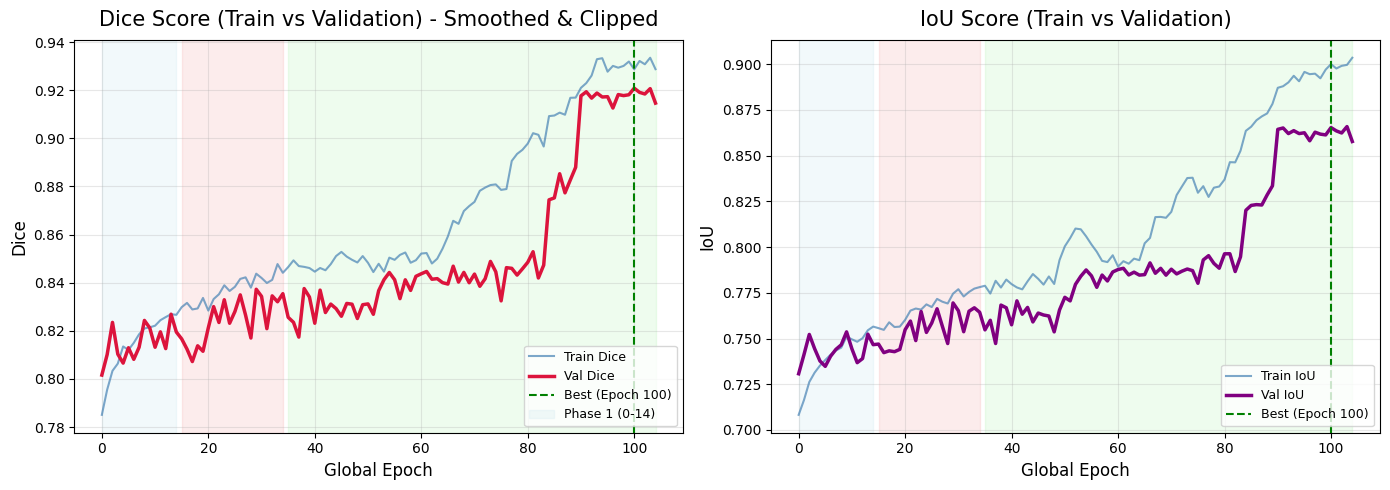


All plots saved → /home/ashu/capstone/main/notebooks/CT_Injection/Results/
Best metrics CSV → /home/ashu/capstone/main/notebooks/CT_Injection/Results/best_metrics.csv
Best model: Epoch 100 | Phase 3 | Dice = 0.9208


In [32]:
# =============================================
#  FULL ANALYSIS: JSON → BEST METRICS → PLOTS (CORRECT PHASE BOUNDARIES)
# =============================================
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ------------------- CONFIG -------------------
json_path = '/home/ashu/capstone/main/notebooks/CT_Injection/history.json'
plots_dir = '/home/ashu/capstone/main/notebooks/CT_Injection/Results'
Path(plots_dir).mkdir(exist_ok=True)

# ------------------- LOAD JSON -------------------
with open(json_path, 'r') as f:
    data = json.load(f)

train_df = pd.DataFrame(data['train'])
val_df   = pd.DataFrame(data['val'])

print(f"Loaded {len(train_df)} train + {len(val_df)} val epochs")
print(f"Phases in data: {sorted(train_df['phase'].unique())}")

phase_bounds = {
    1: (0, 14),
    2: (15, 34),
    3: (35, len(val_df) - 1)
}

# ------------------- FIND BEST EPOCH (by Dice) -------------------
best_idx = val_df['Dice'].idxmax()
best_epoch = int(val_df.loc[best_idx, 'epoch'])
best_phase = int(val_df.loc[best_idx, 'phase'])

def safe_get(df, idx, col, default=np.nan):
    return df.loc[idx, col] if col in df.columns else default

best_metrics = {
    'Epoch': best_epoch,
    'Phase': best_phase,
    'Dice': safe_get(val_df, best_idx, 'Dice'),
    'IoU': safe_get(val_df, best_idx, 'IoU'),
    'F1': safe_get(val_df, best_idx, 'F1'),
    'Precision': safe_get(val_df, best_idx, 'Precision'),
    'Recall': safe_get(val_df, best_idx, 'Recall'),
    'Loss': safe_get(val_df, best_idx, 'Loss'),
}

# ------------------- BEST METRICS TABLE -------------------
print("\n" + "="*70)
print("BEST VALIDATION METRICS (by Dice)")
print("="*70)
best_table = pd.DataFrame([best_metrics]).T
best_table.columns = ['Value']
best_table['Value'] = best_table['Value'].apply(
    lambda x: f"{x:.4f}" if isinstance(x, float) and not np.isnan(x) else ("N/A" if pd.isna(x) else str(x))
)
print(best_table.to_string())
print("="*70)

# ------------------- MERGE TRAIN + VAL -------------------
full_df = pd.merge(train_df, val_df, on='epoch', suffixes=('_train', '_val'), how='outer')
full_df = full_df.sort_values('epoch').reset_index(drop=True)

# ------------------- HELPER: Safe Plot -------------------
def safe_plot(ax, x, y, label=None, color=None, **kwargs):
    if y in full_df.columns and not full_df[y].isna().all():
        ax.plot(full_df[x], full_df[y], label=label, color=color, **kwargs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_to_plot = [
    ('Dice', 'Dice Score (Train vs Validation) - Smoothed & Clipped'),
    ('IoU',  'IoU Score (Train vs Validation)')
]

colors = ['lightblue', 'lightcoral', 'lightgreen']
labels = ['Phase 1 (0-14)', 'Phase 2 (15-34)', 'Phase 3 (35+)']

for ax, (metric, title) in zip(axes, metrics_to_plot):
    safe_plot(ax, 'epoch', f'{metric}_train', label=f'Train {metric}', color='steelblue', alpha=0.7)
    safe_plot(ax, 'epoch', f'{metric}_val',   label=f'Val {metric}',   color='crimson' if metric == 'Dice' else 'purple', linewidth=2.5)
    
    # Best epoch line
    ax.axvline(best_epoch, color='green', linestyle='--', linewidth=1.5, label=f'Best (Epoch {best_epoch})')

    # Phase shading
    for i, (ph, (s, e)) in enumerate(phase_bounds.items()):
        ax.axvspan(s, min(e, len(full_df)-1), alpha=0.15, color=colors[i], label=labels[i] if metric == 'Dice' and i == 0 else "")

    ax.set_title(title, fontsize=15, pad=10)
    ax.set_xlabel('Global Epoch', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{plots_dir}/dice_iou_combined.png", dpi=200, bbox_inches='tight')
plt.show()


best_df = pd.DataFrame([best_metrics])
best_df.to_csv(f"{plots_dir}/best_metrics.csv", index=False)

print(f"\nAll plots saved → {plots_dir}/")
print(f"Best metrics CSV → {plots_dir}/best_metrics.csv")
print(f"Best model: Epoch {best_epoch} | Phase {best_phase} | Dice = {best_metrics['Dice']:.4f}")